### 1. colab 연동

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/cifar100/cifar100.zip /content/
!unzip -q /content/cifar100.zip -d /content/dataset/

Mounted at /content/drive


### 2. CIFAR100 data로 train, test dataset,loader 만들기

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchsummary import summary
import torch.optim.lr_scheduler as lr_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dir = 'dataset/cifar100/train'
test_dir = 'dataset/cifar100/test'

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

aug_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
nonaug_train_dataset = datasets.ImageFolder(root=train_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of testing samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Class names: {train_dataset.classes}')
print(f'Example image shape: {train_dataset[0][0].shape}')

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'te

### 3. 모델 정의


In [ ]:
import torch
import torch.nn as nn

# 기본 블록
class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

# Inception 모듈
class Inception(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super(Inception, self).__init__()
        # 1x1 conv
        self.branch1 = BasicConv2d(in_channels, ch1x1, kernel_size=1)

        # 1x1 conv -> 3x3 conv
        self.branch2 = nn.Sequential(
            BasicConv2d(in_channels, ch3x3red, kernel_size=1),
            BasicConv2d(ch3x3red, ch3x3, kernel_size=3, padding=1)
        )

        # 1x1 conv -> 5x5 conv
        self.branch3 = nn.Sequential(
            BasicConv2d(in_channels, ch5x5red, kernel_size=1),
            BasicConv2d(ch5x5red, ch5x5, kernel_size=5, padding=2)
        )

        # 3x3 max pool -> 1x1 conv
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, pool_proj, kernel_size=1)
        )

    def forward(self, x):
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)
        return torch.cat([branch1, branch2, branch3, branch4], 1)

class GoogLeNet_original(nn.Module):
    def __init__(self, num_classes=100):
        super(GoogLeNet_original, self).__init__()
        
        self.conv1 = BasicConv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool1 = nn.MaxPool2d(3, stride=2, padding=1)
        
        self.conv2 = BasicConv2d(64, 64, kernel_size=1),
        self.conv3 = BasicConv2d(64, 192, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception3a = Inception(192, 64, 96, 128, 16, 32, 32)
        self.inception3b = Inception(256, 128, 128, 192, 32, 96, 64)
        self.maxpool3 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception4a = Inception(480, 192, 96, 208, 16, 48, 64)
        self.inception4b = Inception(512, 160, 112, 224, 24, 64, 64)
        self.inception4c = Inception(512, 128, 128, 256, 24, 64, 64)
        self.inception4d = Inception(512, 112, 144, 288, 32, 64, 64)
        self.inception4e = Inception(528, 256, 160, 320, 32, 128, 128)
        self.maxpool4 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception5a = Inception(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = Inception(832, 384, 192, 384, 48, 128, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.maxpool1(self.conv1(x))
        x = self.maxpool2(self.conv3(self.conv2[0](x))) # conv2 is wrapped in tuple if not careful

        x = self.maxpool3(self.inception3b(self.inception3a(x)))
        x = self.inception4e(self.inception4d(self.inception4c(self.inception4b(self.inception4a(x)))))
        x = self.maxpool4(x)
        x = self.inception5b(self.inception5a(x))

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
import torch
import torch.nn as nn

class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super(Inception, self).__init__()
        self.branch1 = BasicConv2d(in_channels, ch1x1, kernel_size=1)
        self.branch2 = nn.Sequential(
            BasicConv2d(in_channels, ch3x3red, kernel_size=1),
            BasicConv2d(ch3x3red, ch3x3, kernel_size=3, padding=1)
        )
        self.branch3 = nn.Sequential(
            BasicConv2d(in_channels, ch5x5red, kernel_size=1),
            BasicConv2d(ch5x5red, ch5x5, kernel_size=5, padding=2)
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, pool_proj, kernel_size=1)
        )
    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], 1)

class GoogLeNet_custom(nn.Module):
    def __init__(self, num_classes=100):
        super(GoogLeNet_custom, self).__init__()
        # Stem 영역: 7x7 stride 2 -> 3x3 stride 1로 변경하여 해상도 유지
        self.stem = nn.Sequential(
            BasicConv2d(3, 192, kernel_size=7, padding=3)
        )

        # Inception 블록들 (입력 채널수에 맞춰 3a부터 시작)
        self.inception3a = Inception(192, 64, 96, 128, 16, 32, 32)
        self.inception3b = Inception(256, 128, 128, 192, 32, 96, 64)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1) # 16x16

        self.inception4a = Inception(480, 192, 96, 208, 16, 48, 64)
        # ... (중간 Inception 블록들은 원본과 동일하게 쌓거나 필요에 따라 줄임)
        # 가독성을 위해 4a 이후 바로 pool로 넘어가는 예시입니다.
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool(x)
        x = self.inception4a(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

In [ ]:
summary(AlexNet().to(device), (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
         GroupNorm-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          18,496
         GroupNorm-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
 MyCustomNormBlock-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 16, 16]          36,928
         GroupNorm-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
MyCustomNormBlock-11           [-1, 64, 16, 16]               0
           Conv2d-12          [-1, 128, 16, 16]          73,856
        GroupNorm-13          [-1, 128, 16, 16]             256
             ReLU-14          [-1, 128,

### 4. train, test 함수 정의

In [ ]:
from torch.nn.utils import clip_grad_norm_

def train(dataloader , model , loss_fn , optimizer , lr_scheduler):
    size = 0
    num_batches = len(dataloader)
    model.train()
    epoch_loss , epoch_correct = 0 , 0

    for i ,(data_ , target_) in enumerate(dataloader):
        data_ , target_ = data_.to(device), target_.to(device)
        optimizer.zero_grad()

        output_ = model(data_)

        loss = loss_fn(output_, target_)
        loss.backward()
        # clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        pred = output_.argmax(dim=1)
        correct = (pred == target_).sum().item()
        epoch_correct += correct
        epoch_loss += loss.item()
        size += len(data_)

    train_acc = epoch_correct/size
    lr_scheduler.step()

    return train_acc , epoch_loss / num_batches

In [ ]:
def test(dataloader , model , loss_fn):
    size = 0
    num_baches = len(dataloader)
    epoch_loss , epoch_correct= 0 ,0
    with torch.no_grad(): # grad 연산 X
        model.eval() # evaluation dropout 연산시
        for i, (data_ , target_) in enumerate(dataloader):

            data_ , target_ = data_.to(device), target_.to(device)
            output_ = model(data_)
            loss = loss_fn(output_, target_)

            pred = output_.argmax(dim=1)
            correct = (pred == target_).sum().item()
            epoch_correct += correct
            epoch_loss += loss.item()
            size += len(data_)

    test_acc = epoch_correct/size

    return test_acc  , epoch_loss / num_baches

### 5. log 및 모델 정의

In [ ]:
batchsize_train_logs = { "data_augmentation_acc":[],
                        "non_data_augmentation_acc":[],
                        }
batchsize_test_logs = { "data_augmentation_acc":[],
                        "non_data_augmentation_acc":[],
                        }

models = {
    "data_augmentation_model": MyCustomNormNet(groupnorm = False).to(device),
    "non_data_augmentation_model": MyCustomNormNet(groupnorm = True).to(device),
}

models_name = list(models.keys())

### 6. 학습

In [ ]:
from tqdm.notebook import tqdm
EPOCHS = 70
criterion = nn.CrossEntropyLoss()

# batch_size별 모델 학습
batchsize_test_logs_name = list(batchsize_test_logs.keys())
for iteration in range(7):
    batch_size_iter = 7-iteration

    # group norm 학습-----------------------------------------------------------------
    current_model = models["data_augmentation_model"]
    optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    print('='*50)
    print('data_augmentation')
    for epoch in tqdm(range(EPOCHS)):
        train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
        test_acc, test_loss = test(test_loader, current_model, criterion)

        if(epoch%5 == 0 or epoch == EPOCHS - 1):
            print(f'data_augmentation_train_acc:{train_acc:.4f} data_augmentation_test_acc:{test_acc:.4f}')

    batchsize_train_logs["data_augmentation_acc"].append(train_acc)
    batchsize_test_logs["data_augmentation_acc"].append(test_acc)

    # batch norm 학습--------------------------------------------------------------------
    current_model = models["non_data_augmentation_model"]
    optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    print('='*50)
    print('non_data_augmentation')
    for epoch in tqdm(range(EPOCHS)):
        train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
        test_acc, test_loss = test(test_loader, current_model, criterion)

        if(epoch%5 == 0 or epoch == EPOCHS -1):
            print(f'batchnorm_train_acc:{train_acc:.4f} batchnorm_test_acc:{test_acc:.4f}')

    batchsize_train_logs["non_data_augmentationacc"].append(train_acc)
    batchsize_test_logs["non_data_augmentationacc"].append(test_acc)

current_batch_size: 128 - group_norm


  0%|          | 0/70 [00:00<?, ?it/s]

groupnorm_train_acc:0.0280 groupnorm_test_acc:0.0570
groupnorm_train_acc:0.1845 groupnorm_test_acc:0.2219
groupnorm_train_acc:0.3040 groupnorm_test_acc:0.3302
groupnorm_train_acc:0.4014 groupnorm_test_acc:0.4420
groupnorm_train_acc:0.4761 groupnorm_test_acc:0.4998
groupnorm_train_acc:0.5340 groupnorm_test_acc:0.5137
groupnorm_train_acc:0.5820 groupnorm_test_acc:0.5706
groupnorm_train_acc:0.6279 groupnorm_test_acc:0.5838
groupnorm_train_acc:0.6686 groupnorm_test_acc:0.6077
groupnorm_train_acc:0.7099 groupnorm_test_acc:0.6226
groupnorm_train_acc:0.7472 groupnorm_test_acc:0.6276
groupnorm_train_acc:0.7857 groupnorm_test_acc:0.6362
groupnorm_train_acc:0.8155 groupnorm_test_acc:0.6449
groupnorm_train_acc:0.8366 groupnorm_test_acc:0.6499
groupnorm_train_acc:0.8391 groupnorm_test_acc:0.6506
current_batch_size: 128 - batch_norm


  0%|          | 0/70 [00:00<?, ?it/s]

batchnorm_train_acc:0.0448 batchnorm_test_acc:0.0947
batchnorm_train_acc:0.2651 batchnorm_test_acc:0.2884
batchnorm_train_acc:0.4279 batchnorm_test_acc:0.4335
batchnorm_train_acc:0.5299 batchnorm_test_acc:0.5154
batchnorm_train_acc:0.5940 batchnorm_test_acc:0.5453
batchnorm_train_acc:0.6426 batchnorm_test_acc:0.6029
batchnorm_train_acc:0.6816 batchnorm_test_acc:0.6263
batchnorm_train_acc:0.7142 batchnorm_test_acc:0.6228
batchnorm_train_acc:0.7472 batchnorm_test_acc:0.6560
batchnorm_train_acc:0.7765 batchnorm_test_acc:0.6450
batchnorm_train_acc:0.8064 batchnorm_test_acc:0.6710
batchnorm_train_acc:0.8350 batchnorm_test_acc:0.6790
batchnorm_train_acc:0.8616 batchnorm_test_acc:0.6814
batchnorm_train_acc:0.8829 batchnorm_test_acc:0.6889
batchnorm_train_acc:0.8973 batchnorm_test_acc:0.6894
current_batch_size: 64 - group_norm


...

batchnorm_train_acc:0.0646 batchnorm_test_acc:0.1262
batchnorm_train_acc:0.2352 batchnorm_test_acc:0.3527
batchnorm_train_acc:0.2683 batchnorm_test_acc:0.3685
batchnorm_train_acc:0.2893 batchnorm_test_acc:0.3683
batchnorm_train_acc:0.2968 batchnorm_test_acc:0.3786
batchnorm_train_acc:0.3143 batchnorm_test_acc:0.3976
batchnorm_train_acc:0.3273 batchnorm_test_acc:0.4185
batchnorm_train_acc:0.3524 batchnorm_test_acc:0.4321
batchnorm_train_acc:0.3734 batchnorm_test_acc:0.4654
batchnorm_train_acc:0.3987 batchnorm_test_acc:0.4687
batchnorm_train_acc:0.4294 batchnorm_test_acc:0.5060
batchnorm_train_acc:0.4676 batchnorm_test_acc:0.5402
batchnorm_train_acc:0.5071 batchnorm_test_acc:0.5733
batchnorm_train_acc:0.5574 batchnorm_test_acc:0.6115
batchnorm_train_acc:0.6084 batchnorm_test_acc:0.6348
current_batch_size: 2 - group_norm


  0%|          | 0/70 [00:00<?, ?it/s]

groupnorm_train_acc:0.0418 groupnorm_test_acc:0.0797
groupnorm_train_acc:0.1364 groupnorm_test_acc:0.1783
groupnorm_train_acc:0.1309 groupnorm_test_acc:0.1384
groupnorm_train_acc:0.1542 groupnorm_test_acc:0.1672
groupnorm_train_acc:0.1747 groupnorm_test_acc:0.2123
groupnorm_train_acc:0.1965 groupnorm_test_acc:0.2151
groupnorm_train_acc:0.2181 groupnorm_test_acc:0.2460
groupnorm_train_acc:0.2486 groupnorm_test_acc:0.2676
groupnorm_train_acc:0.2825 groupnorm_test_acc:0.3208
groupnorm_train_acc:0.3213 groupnorm_test_acc:0.3910
groupnorm_train_acc:0.3782 groupnorm_test_acc:0.4133
groupnorm_train_acc:0.4394 groupnorm_test_acc:0.4555
groupnorm_train_acc:0.5184 groupnorm_test_acc:0.5297
groupnorm_train_acc:0.6114 groupnorm_test_acc:0.5850
groupnorm_train_acc:0.6597 groupnorm_test_acc:0.6113
current_batch_size: 2 - batch_norm


  0%|          | 0/70 [00:00<?, ?it/s]

batchnorm_train_acc:0.0401 batchnorm_test_acc:0.0771
batchnorm_train_acc:0.1827 batchnorm_test_acc:0.2215
batchnorm_train_acc:0.1906 batchnorm_test_acc:0.2538
batchnorm_train_acc:0.2037 batchnorm_test_acc:0.2619
batchnorm_train_acc:0.2089 batchnorm_test_acc:0.2446
batchnorm_train_acc:0.2198 batchnorm_test_acc:0.2623
batchnorm_train_acc:0.2340 batchnorm_test_acc:0.2866
batchnorm_train_acc:0.2496 batchnorm_test_acc:0.2971
batchnorm_train_acc:0.2711 batchnorm_test_acc:0.3215
batchnorm_train_acc:0.2905 batchnorm_test_acc:0.3303
batchnorm_train_acc:0.3222 batchnorm_test_acc:0.3591
batchnorm_train_acc:0.3594 batchnorm_test_acc:0.3810
batchnorm_train_acc:0.4078 batchnorm_test_acc:0.4411
batchnorm_train_acc:0.4629 batchnorm_test_acc:0.4735
batchnorm_train_acc:0.5147 batchnorm_test_acc:0.4939


### 7. 시각화

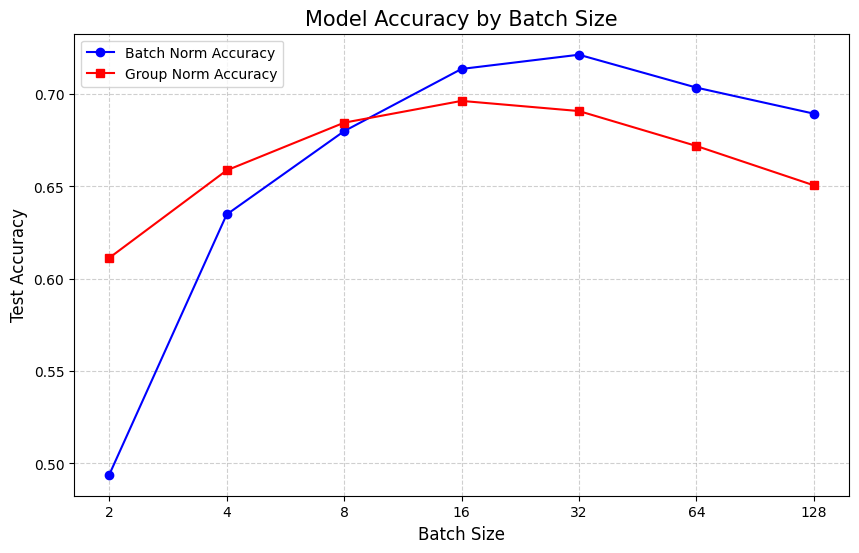

In [ ]:
import matplotlib.pyplot as plt

# batch size별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]

bn_acc_reversed = batchsize_test_logs["batch_norm_acc"][::-1]
gn_acc_reversed = batchsize_test_logs["group_norm_acc"][::-1]

plt.plot(batchsize__, bn_acc_reversed, 'b-o', label='Batch Norm Accuracy')
plt.plot(batchsize__, gn_acc_reversed, 'r-s', label='Group Norm Accuracy')
plt.xscale('log', base=2)
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy by Batch Size', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

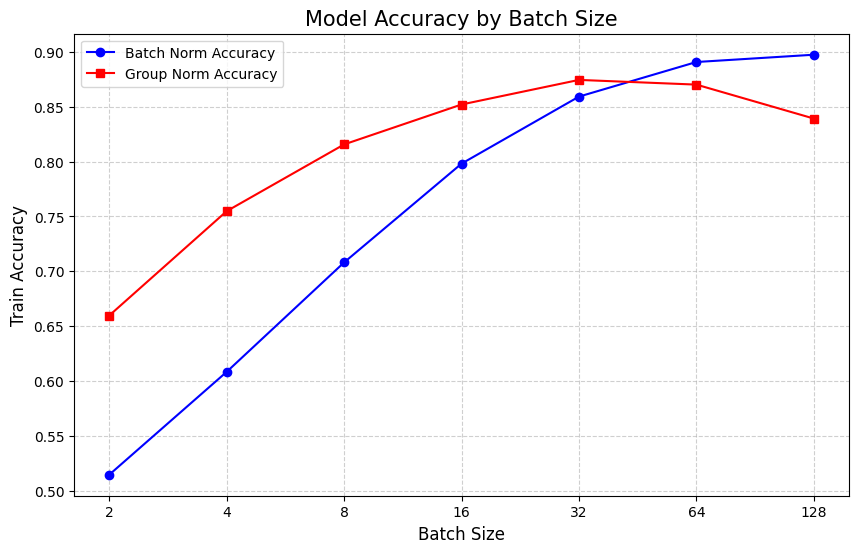

In [ ]:
import matplotlib.pyplot as plt

# batch size별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]

bn_acc_reversed = batchsize_train_logs["batch_norm_acc"][::-1]
gn_acc_reversed = batchsize_train_logs["group_norm_acc"][::-1]

plt.plot(batchsize__, bn_acc_reversed, 'b-o', label='Batch Norm Accuracy')
plt.plot(batchsize__, gn_acc_reversed, 'r-s', label='Group Norm Accuracy')
plt.xscale('log', base=2)
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy by Batch Size', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

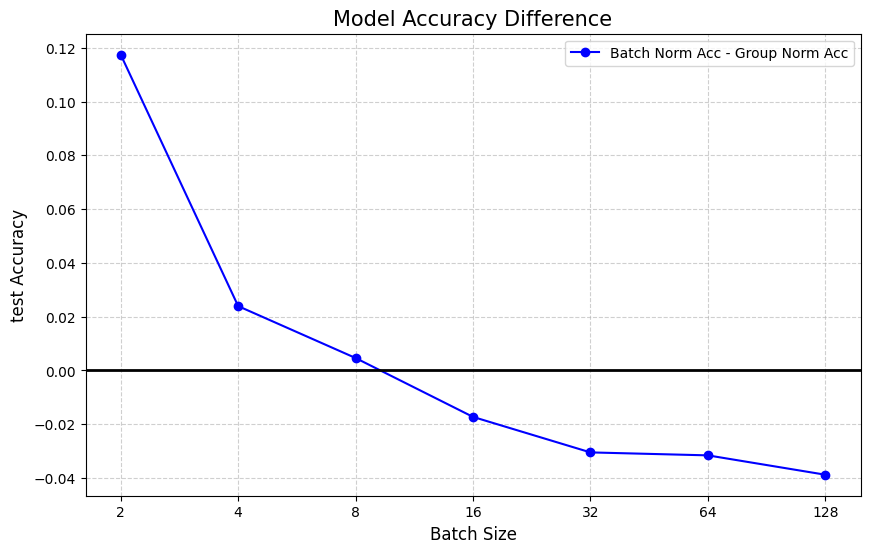

In [ ]:
import matplotlib.pyplot as plt

# batch size별 정확도 얼마나 차이나는지 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]


bn_acc = batchsize_test_logs["batch_norm_acc"][::-1]
gn_acc = batchsize_test_logs["group_norm_acc"][::-1]
diff_acc = [gn - bn for gn, bn in zip(gn_acc, bn_acc)]

plt.plot(batchsize__, diff_acc, 'b-o', label='Batch Norm Acc - Group Norm Acc')
plt.xscale('log', base=2)
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy Difference', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=2, linestyle='-')
plt.show()